In [24]:
import pandas as pd

In [25]:
df = pd.read_csv("./data/stock-data.csv")
print(df.head())
print('\n')
print(df.info())



         Date  Close  Start   High    Low  Volume
0  2018-07-02  10100  10850  10900  10000  137977
1  2018-06-29  10700  10550  10900   9990  170253
2  2018-06-28  10400  10900  10950  10150  155769
3  2018-06-27  10900  10800  11050  10500  133548
4  2018-06-26  10800  10900  11000  10700   63039


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    20 non-null     str  
 1   Close   20 non-null     int64
 2   Start   20 non-null     int64
 3   High    20 non-null     int64
 4   Low     20 non-null     int64
 5   Volume  20 non-null     int64
dtypes: int64(5), str(1)
memory usage: 1.1 KB
None


In [26]:
# 문자열을 timestamp로 변환

df["new_Date"] = pd.to_datetime(df['Date'])
print(df.head())
print("\n")
print(type(df["new_Date"]))

         Date  Close  Start   High    Low  Volume   new_Date
0  2018-07-02  10100  10850  10900  10000  137977 2018-07-02
1  2018-06-29  10700  10550  10900   9990  170253 2018-06-29
2  2018-06-28  10400  10900  10950  10150  155769 2018-06-28
3  2018-06-27  10900  10800  11050  10500  133548 2018-06-27
4  2018-06-26  10800  10900  11000  10700   63039 2018-06-26


<class 'pandas.Series'>


In [27]:
df = df.set_index("new_Date")
df = df.drop("Date", axis=1)
df.head()

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-07-02,10100,10850,10900,10000,137977
2018-06-29,10700,10550,10900,9990,170253
2018-06-28,10400,10900,10950,10150,155769
2018-06-27,10900,10800,11050,10500,133548
2018-06-26,10800,10900,11000,10700,63039


In [28]:
pd.DatetimeIndex(["2022-12-25", "2023/01/25"])

DatetimeIndex(['2022-12-25', '2023-01-25'], dtype='datetime64[us]', freq=None)

In [29]:
pd.Timestamp("2023-12-25")

Timestamp('2023-12-25 00:00:00')

In [30]:
# pd.to_datetime("2023년 12월 25일")
pd.to_datetime("2023년 12월 25일", format="%Y년 %m월 %d일")



Timestamp('2023-12-25 00:00:00')

In [31]:
# timestam을 period로 변환

dates = [
    "2019-01-01",
    "2020-03-01",
    "2021-06-01"
]

ts_dates = pd.to_datetime(dates)
ts_dates

pr_day = ts_dates.to_period(freq="D")
pr_day
pr_month = ts_dates.to_period(freq="M")
print(pr_month)
pr_year = ts_dates.to_period(freq="Y")
print(pr_year)


PeriodIndex(['2019-01', '2020-03', '2021-06'], dtype='period[M]')
PeriodIndex(['2019', '2020', '2021'], dtype='period[Y-DEC]')


In [32]:
# 시계열 데이터 만들기

ts_ms = pd.date_range(
    start="2024-01-01",
    end=None,
    periods=6,
    freq="MS",
    tz="Asia/Seoul"
)

print(ts_ms)


DatetimeIndex(['2024-01-01 00:00:00+09:00', '2024-02-01 00:00:00+09:00',
               '2024-03-01 00:00:00+09:00', '2024-04-01 00:00:00+09:00',
               '2024-05-01 00:00:00+09:00', '2024-06-01 00:00:00+09:00'],
              dtype='datetime64[us, Asia/Seoul]', freq='MS')


In [33]:
ts_me = pd.date_range(
    "2024-01-01",
    periods=6,
    freq="ME",
    tz="Asia/Seoul"

)

print(ts_me)



DatetimeIndex(['2024-01-31 00:00:00+09:00', '2024-02-29 00:00:00+09:00',
               '2024-03-31 00:00:00+09:00', '2024-04-30 00:00:00+09:00',
               '2024-05-31 00:00:00+09:00', '2024-06-30 00:00:00+09:00'],
              dtype='datetime64[us, Asia/Seoul]', freq='ME')


In [34]:
ts_3m = pd.date_range(
    "2024-01-01",
    periods=6,
    freq="3MS",
    tz="Asia/Seoul"
)

ts_3m

DatetimeIndex(['2024-01-01 00:00:00+09:00', '2024-04-01 00:00:00+09:00',
               '2024-07-01 00:00:00+09:00', '2024-10-01 00:00:00+09:00',
               '2025-01-01 00:00:00+09:00', '2025-04-01 00:00:00+09:00'],
              dtype='datetime64[us, Asia/Seoul]', freq='3MS')

In [35]:
#시계열데이터 활용

import pandas as pd

df = pd.read_csv("./data/stock-data.csv")


df["new_Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Close,Start,High,Low,Volume,new_Date
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26


In [36]:
df["year"] = df["new_Date"].dt.year
df["month"] = df["new_Date"].dt.month
df["day"] = df["new_Date"].dt.day

df.head()

,Date,Close,Start,High,Low,Volume,new_Date,year,month,day
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02,2018,7,2
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26


In [37]:
df

,Date,Close,Start,High,Low,Volume,new_Date,year,month,day
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02,2018,7,2
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26
5,2018-06-25,11150,11400,11450,11000,55519,2018-06-25,2018,6,25
6,2018-06-22,11300,11250,11450,10750,134805,2018-06-22,2018,6,22
7,2018-06-21,11200,11350,11750,11200,133002,2018-06-21,2018,6,21
8,2018-06-20,11550,11200,11600,10900,308596,2018-06-20,2018,6,20
9,2018-06-19,11300,11850,11950,11300,180656,2018-06-19,2018,6,19


In [38]:
df["Dates_yr"] = df["new_Date"].dt.to_period(freq='Y')
df["Date_m"] = df["new_Date"].dt.to_period(freq="M")
df.head()

,Date,Close,Start,High,Low,Volume,new_Date,year,month,day,Dates_yr,Date_m
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02,2018,7,2,2018,2018-07
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29,2018,2018-06
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28,2018,2018-06
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27,2018,2018-06
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26,2018,2018-06


In [39]:
# 날짜 데이터 분리

cond = df["Date_m"].astype(str).str.fullmatch("2018-06")  #2018년 6월에 해당하는 데이터를 다가지고온다.
df_jun = df[cond]
df_jun.head(29)

,Date,Close,Start,High,Low,Volume,new_Date,year,month,day,Dates_yr,Date_m
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29,2018,2018-06
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28,2018,2018-06
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27,2018,2018-06
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26,2018,2018-06
5,2018-06-25,11150,11400,11450,11000,55519,2018-06-25,2018,6,25,2018,2018-06
6,2018-06-22,11300,11250,11450,10750,134805,2018-06-22,2018,6,22,2018,2018-06
7,2018-06-21,11200,11350,11750,11200,133002,2018-06-21,2018,6,21,2018,2018-06
8,2018-06-20,11550,11200,11600,10900,308596,2018-06-20,2018,6,20,2018,2018-06
9,2018-06-19,11300,11850,11950,11300,180656,2018-06-19,2018,6,19,2018,2018-06
10,2018-06-18,12000,13400,13400,12000,309787,2018-06-18,2018,6,18,2018,2018-06


In [40]:
# 날짜데이터 분리2

cond = df["Date_m"] == pd.Period("2018-06")
df[cond]


,Date,Close,Start,High,Low,Volume,new_Date,year,month,day,Dates_yr,Date_m
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29,2018,2018-06
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28,2018,2018-06
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27,2018,2018-06
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26,2018,2018-06
5,2018-06-25,11150,11400,11450,11000,55519,2018-06-25,2018,6,25,2018,2018-06
6,2018-06-22,11300,11250,11450,10750,134805,2018-06-22,2018,6,22,2018,2018-06
7,2018-06-21,11200,11350,11750,11200,133002,2018-06-21,2018,6,21,2018,2018-06
8,2018-06-20,11550,11200,11600,10900,308596,2018-06-20,2018,6,20,2018,2018-06
9,2018-06-19,11300,11850,11950,11300,180656,2018-06-19,2018,6,19,2018,2018-06
10,2018-06-18,12000,13400,13400,12000,309787,2018-06-18,2018,6,18,2018,2018-06


In [41]:
cond2 = df["Date_m"] == "2018-06"
df[cond2]

,Date,Close,Start,High,Low,Volume,new_Date,year,month,day,Dates_yr,Date_m
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29,2018,2018-06
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28,2018,2018-06
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27,2018,2018-06
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26,2018,2018-06
5,2018-06-25,11150,11400,11450,11000,55519,2018-06-25,2018,6,25,2018,2018-06
6,2018-06-22,11300,11250,11450,10750,134805,2018-06-22,2018,6,22,2018,2018-06
7,2018-06-21,11200,11350,11750,11200,133002,2018-06-21,2018,6,21,2018,2018-06
8,2018-06-20,11550,11200,11600,10900,308596,2018-06-20,2018,6,20,2018,2018-06
9,2018-06-19,11300,11850,11950,11300,180656,2018-06-19,2018,6,19,2018,2018-06
10,2018-06-18,12000,13400,13400,12000,309787,2018-06-18,2018,6,18,2018,2018-06


In [42]:
df_jun = df_jun.set_index("new_Date")
df_jun.head()

,Date,Close,Start,High,Low,Volume,year,month,day,Dates_yr,Date_m
new_Date,,,,,,,,,,,
2018-06-29,2018-06-29,10700,10550,10900,9990,170253,2018,6,29,2018,2018-06
2018-06-28,2018-06-28,10400,10900,10950,10150,155769,2018,6,28,2018,2018-06
2018-06-27,2018-06-27,10900,10800,11050,10500,133548,2018,6,27,2018,2018-06
2018-06-26,2018-06-26,10800,10900,11000,10700,63039,2018,6,26,2018,2018-06
2018-06-25,2018-06-25,11150,11400,11450,11000,55519,2018,6,25,2018,2018-06


In [43]:
# 시간인덱스 

##오름차순 정렬
df = pd.read_csv("./data/stock-data.csv")
df["new_Date"] = pd.to_datetime(df["Date"])

df.set_index("new_Date").sort_index()
df.head()

,Date,Close,Start,High,Low,Volume,new_Date
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26


In [44]:
df.loc["2018-06-27"]

KeyError: '2018-06-27'

In [ ]:
df.loc["2018-06"]

KeyError: '2018-06'

In [ ]:
df.loc["2018-06-27": "2018-07-02"]

,Date,Close,Start,High,Low,Volume,new_Date


In [ ]:
cond = df.index < "2018-06-05"
df[cond]

TypeError: Invalid comparison between dtype=int64 and str

In [ ]:
pd.Timestamp(2018,6,27)

Timestamp('2018-06-27 00:00:00')

In [ ]:
# 시간 인덱스 활용

df.loc[pd.Timestamp(2018,6,27) : pd.Timestamp(2018,7,2)]

TypeError: '<' not supported between instances of 'int' and 'Timestamp'

In [ ]:
#시간으로 만들어주는 함수

pd.Timestamp(2018,4,27,10,10,0)

Timestamp('2018-04-27 10:10:00')

In [ ]:
df.loc[pd.Timestamp(2018,4,27,10,10,0):pd.Timestamp(2018,7,23,23,59,59)]

TypeError: '<' not supported between instances of 'int' and 'Timestamp'

In [ ]:
print(pd.Timedelta("1 days"))
print(pd.Timedelta(days=1))
print(pd.Timedelta("1 days 1 hours 1 miniutes 1 seconds"))
print(pd.Timedelta("days=1, hours=1, minutes=1, seconds=1"))

1 days 00:00:00
1 days 00:00:00


ValueError: invalid unit abbreviation: miniutes

In [ ]:
pd.to_timedelta(["1 days","1 hours"])

TimedeltaIndex(['1 days 00:00:00', '0 days 01:00:00'], dtype='timedelta64[us]', freq=None)

In [ ]:
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      20 non-null     str           
 1   Close     20 non-null     int64         
 2   Start     20 non-null     int64         
 3   High      20 non-null     int64         
 4   Low       20 non-null     int64         
 5   Volume    20 non-null     int64         
 6   new_Date  20 non-null     datetime64[us]
dtypes: datetime64[us](1), int64(5), str(1)
memory usage: 1.2 KB


In [45]:
a = df.index
print(a)

RangeIndex(start=0, stop=20, step=1)


In [46]:
b = pd.Timestamp("2018-07-03") - a
print(b)

TypeError: Addition/subtraction of integers and integer-arrays with Timestamp is no longer supported.  Instead of adding/subtracting `n`, use `n * obj.freq`

In [ ]:
a - pd.Timedelta(days=1)

In [47]:
print(c.min())

NameError: name 'c' is not defined

In [48]:
print(c.max())

NameError: name 'c' is not defined

In [51]:
import pandas as pd

df = pd.read_csv("./data/stock-data.csv")
df.head()

,Date,Close,Start,High,Low,Volume
0,2018-07-02,10100,10850,10900,10000,137977
1,2018-06-29,10700,10550,10900,9990,170253
2,2018-06-28,10400,10900,10950,10150,155769
3,2018-06-27,10900,10800,11050,10500,133548
4,2018-06-26,10800,10900,11000,10700,63039


In [54]:
df["new_Date"] = pd.to_datetime(df["Date"])
df = df.drop(columns=["Date"])
df.head()

,Close,Start,High,Low,Volume,new_Date
0,10100,10850,10900,10000,137977,2018-07-02
1,10700,10550,10900,9990,170253,2018-06-29
2,10400,10900,10950,10150,155769,2018-06-28
3,10900,10800,11050,10500,133548,2018-06-27
4,10800,10900,11000,10700,63039,2018-06-26


In [56]:
df = df.set_index("new_Date").sort_index()
ts = df.head(10)
ts

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900,11800,12100,11750,32062
2018-06-04,11900,11900,12200,11700,25171
2018-06-05,12150,11800,12250,11800,42485
2018-06-07,11950,12200,12300,11900,49088
2018-06-08,11950,11950,12200,11800,59258
2018-06-11,11950,12000,12250,11950,62293
2018-06-12,13200,12200,13300,12050,558148
2018-06-14,13450,13200,13700,13150,347451
2018-06-15,13400,13600,13600,12900,201376


In [57]:
ts.shift(1)

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,NaN,NaN,NaN,NaN,NaN
2018-06-04,11900.0,11800.0,12100.0,11750.0,32062.0
2018-06-05,11900.0,11900.0,12200.0,11700.0,25171.0
2018-06-07,12150.0,11800.0,12250.0,11800.0,42485.0
2018-06-08,11950.0,12200.0,12300.0,11900.0,49088.0
2018-06-11,11950.0,11950.0,12200.0,11800.0,59258.0
2018-06-12,11950.0,12000.0,12250.0,11950.0,62293.0
2018-06-14,13200.0,12200.0,13300.0,12050.0,558148.0
2018-06-15,13450.0,13200.0,13700.0,13150.0,347451.0


In [58]:
ts.shift(-2)

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,12150.0,11800.0,12250.0,11800.0,42485.0
2018-06-04,11950.0,12200.0,12300.0,11900.0,49088.0
2018-06-05,11950.0,11950.0,12200.0,11800.0,59258.0
2018-06-07,11950.0,12000.0,12250.0,11950.0,62293.0
2018-06-08,13200.0,12200.0,13300.0,12050.0,558148.0
2018-06-11,13450.0,13200.0,13700.0,13150.0,347451.0
2018-06-12,13400.0,13600.0,13600.0,12900.0,201376.0
2018-06-14,12000.0,13400.0,13400.0,12000.0,309787.0
2018-06-15,NaN,NaN,NaN,NaN,NaN


In [59]:
ts.shift(3, freq="D")

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-04,11900,11800,12100,11750,32062
2018-06-07,11900,11900,12200,11700,25171
2018-06-08,12150,11800,12250,11800,42485
2018-06-10,11950,12200,12300,11900,49088
2018-06-11,11950,11950,12200,11800,59258
2018-06-14,11950,12000,12250,11950,62293
2018-06-15,13200,12200,13300,12050,558148
2018-06-17,13450,13200,13700,13150,347451
2018-06-18,13400,13600,13600,12900,201376


In [60]:
ts.asfreq("5D")

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900.0,11800.0,12100.0,11750.0,32062.0
2018-06-06,NaN,NaN,NaN,NaN,NaN
2018-06-11,11950.0,12000.0,12250.0,11950.0,62293.0
2018-06-16,NaN,NaN,NaN,NaN,NaN


In [61]:
ts.asfreq("5D", method="bfill")

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900,11800,12100,11750,32062
2018-06-06,11950,12200,12300,11900,49088
2018-06-11,11950,12000,12250,11950,62293
2018-06-16,12000,13400,13400,12000,309787


In [62]:
# 시계열 데이터 시각화.
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [64]:
df = pd.read_csv("./data/stock-data.csv")

df["new_Date"] = pd.to_datetime(df["Date"])
df = df.drop(columns=["Date"])
df = df.set_index("new_Date").sort_index()
df

,Close,Start,High,Low,Volume
new_Date,,,,,
2018-06-01,11900,11800,12100,11750,32062
2018-06-04,11900,11900,12200,11700,25171
2018-06-05,12150,11800,12250,11800,42485
2018-06-07,11950,12200,12300,11900,49088
2018-06-08,11950,11950,12200,11800,59258
2018-06-11,11950,12000,12250,11950,62293
2018-06-12,13200,12200,13300,12050,558148
2018-06-14,13450,13200,13700,13150,347451
2018-06-15,13400,13600,13600,12900,201376


<Axes: xlabel='new_Date'>

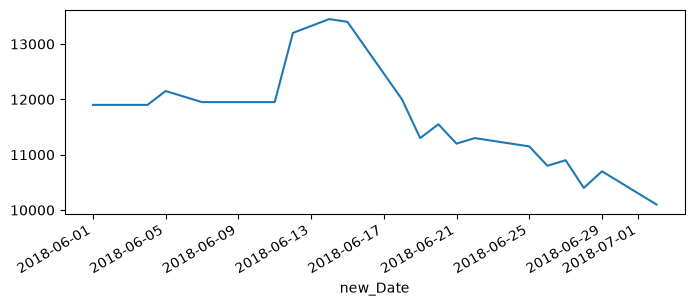

In [67]:
df["Close"].plot(figsize=(8,3))

<Axes: xlabel='new_Date'>

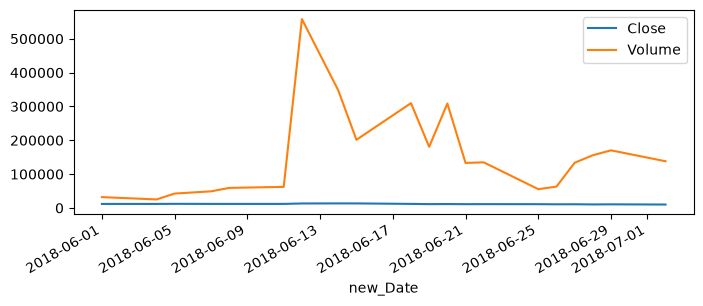

In [70]:
df[["Close", "Volume"]].plot(figsize=(8,3))

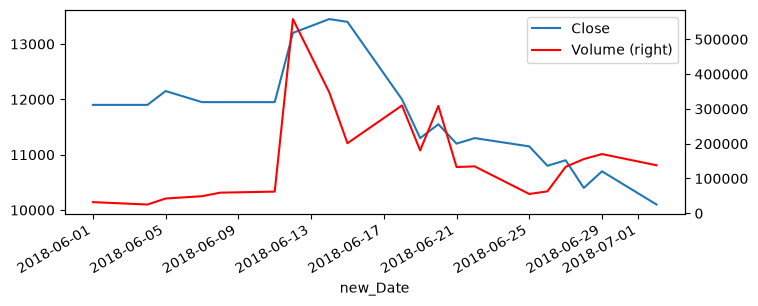

In [74]:
df["Close"].plot(label="Close", legend=True, figsize=(8,3))
df["Volume"].plot(secondary_y=True, style="r", label="Volume",legend=True)

plt.show()

<Axes: xlabel='new_Date'>

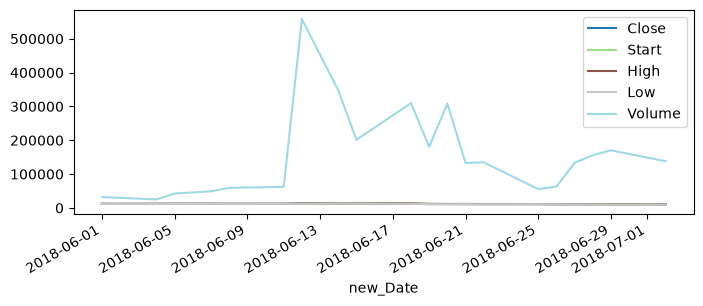

In [75]:
df.plot(figsize=(8,3), colormap="tab20")

array([[<Axes: xlabel='new_Date'>, <Axes: xlabel='new_Date'>,
        <Axes: xlabel='new_Date'>],
       [<Axes: xlabel='new_Date'>, <Axes: xlabel='new_Date'>,
        <Axes: xlabel='new_Date'>]], dtype=object)

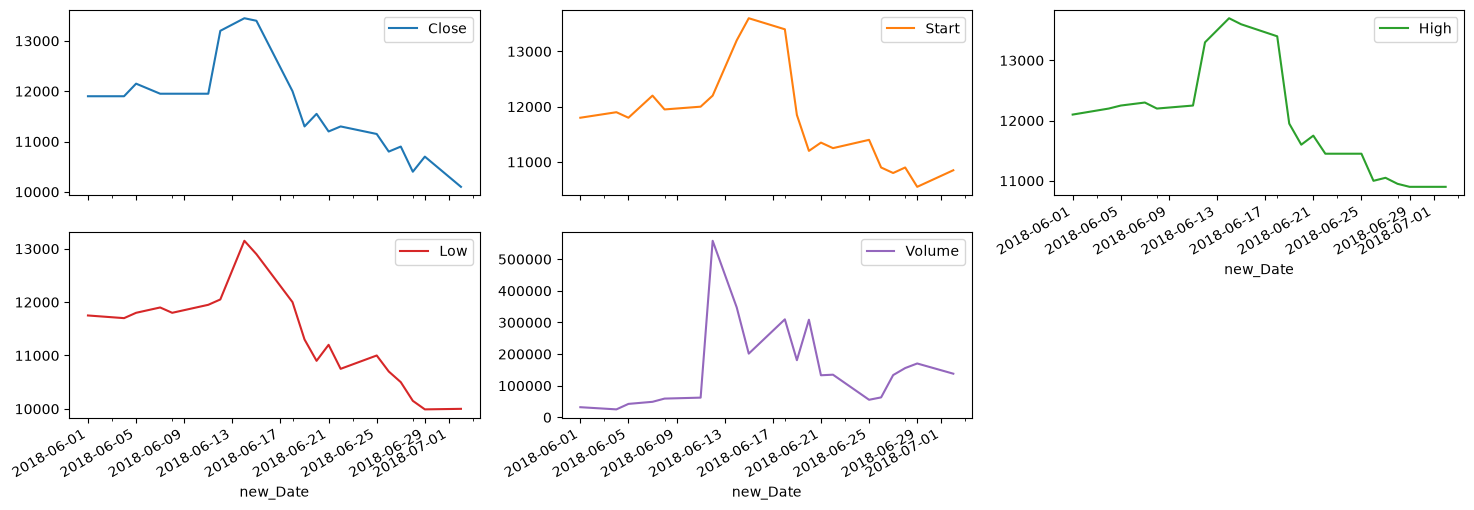

In [77]:
axes = df.plot(
    subplots=True,
    layout=(2,3),
    figsize=(18,6),
    sharex=True,
    sharey=False
)

axes

(<Figure size 1600x800 with 4 Axes>,
 array([[<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >]], dtype=object))

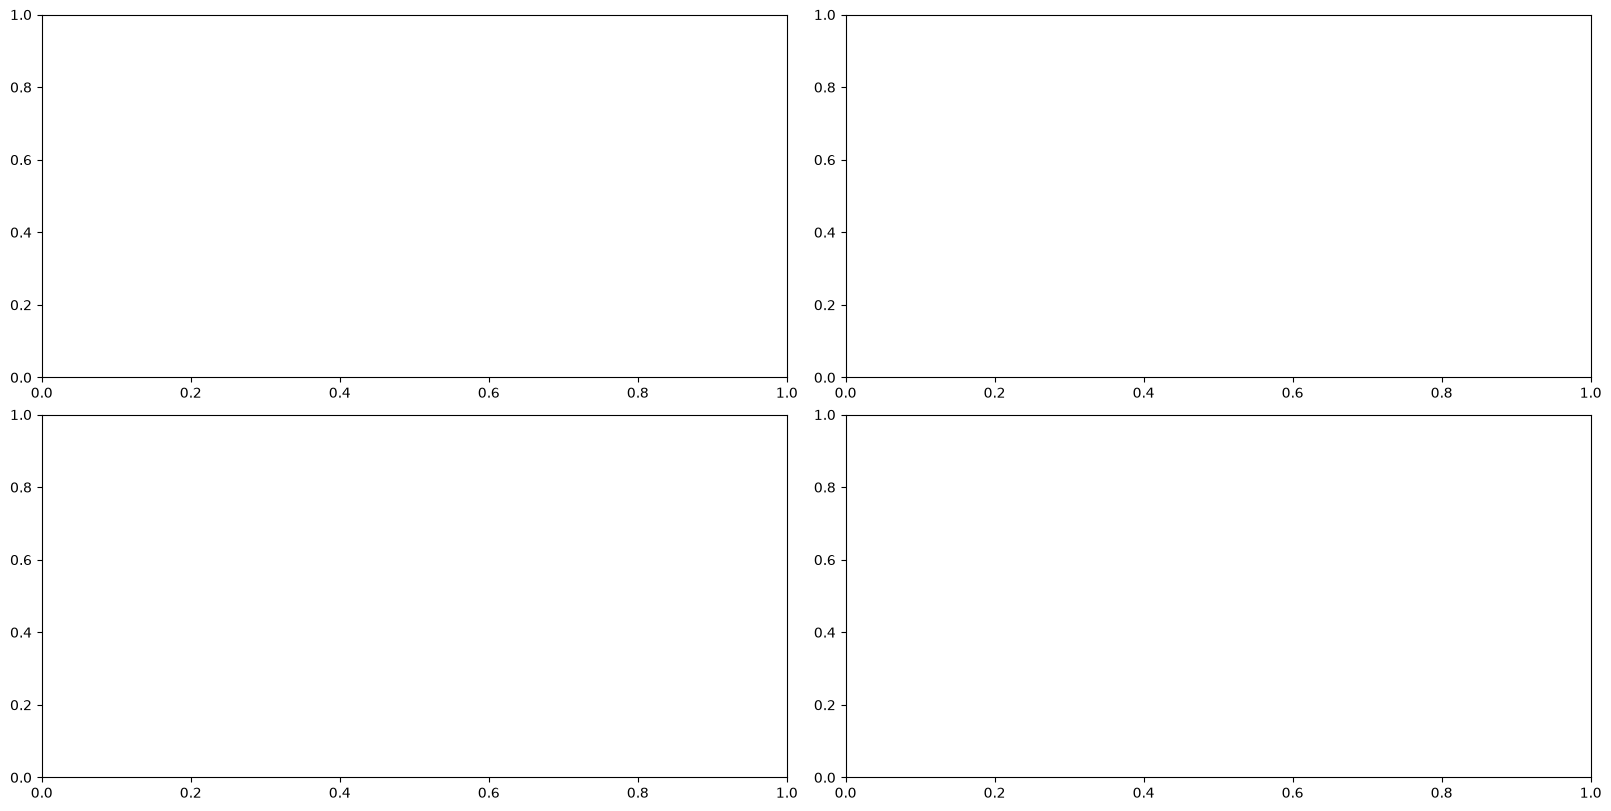

In [ ]:
fig.axes = plt.subplots(nrows=2, ncols=2,
            figsize=(16,8),
            constrained_layout=True,
             )

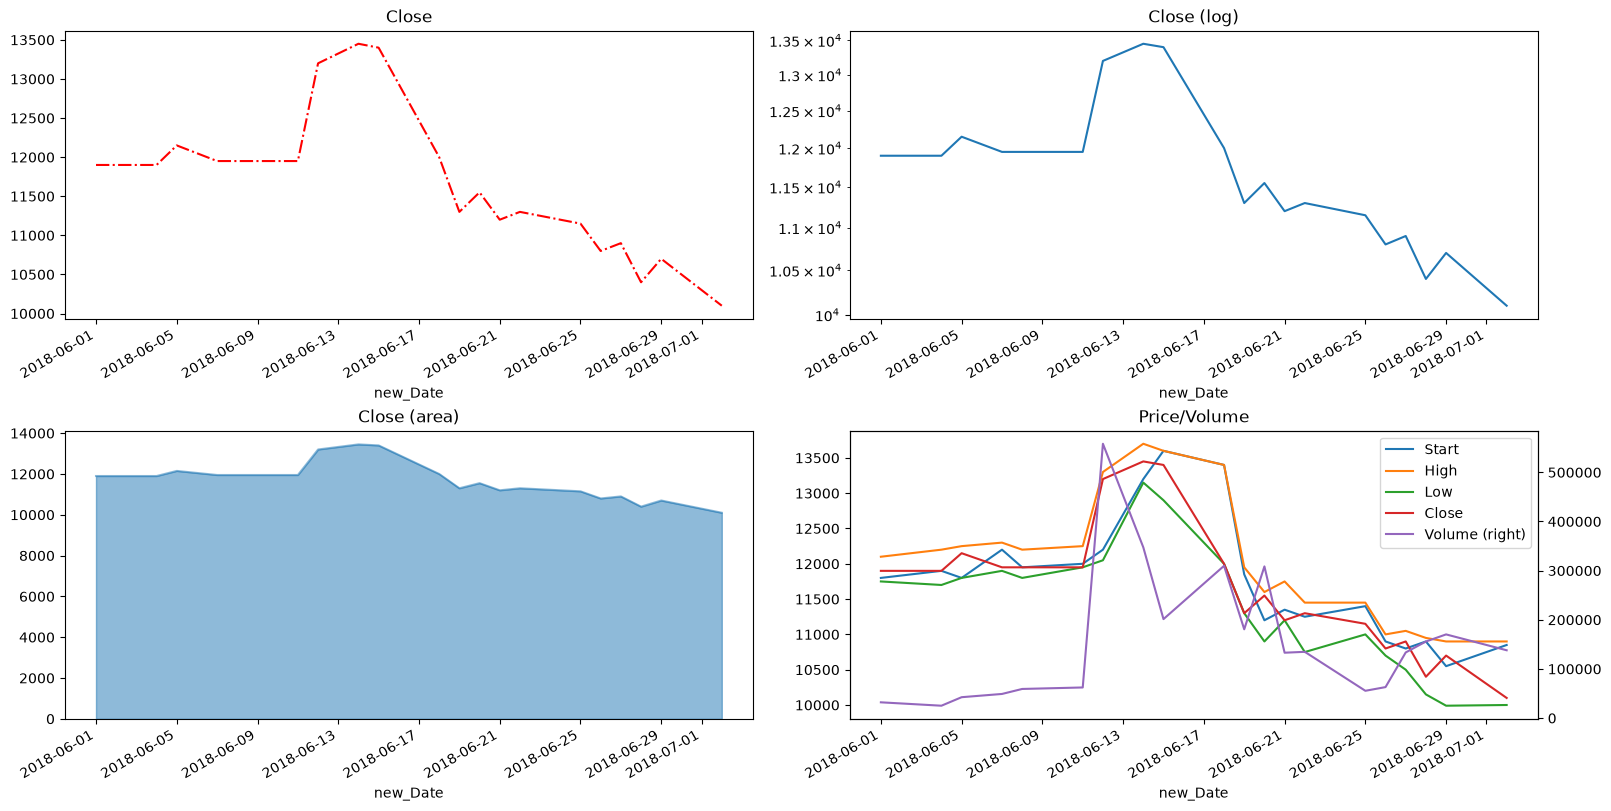

In [84]:
fig, axes = plt.subplots(nrows=2, ncols=2,
            figsize=(16,8),
            constrained_layout=True,
             )


df["Close"].plot(
    ax=axes[0,0],
    style="r-."
)

axes[0,0].set_title("Close")

df["Close"].plot(ax=axes[0,1], logy=True)
axes[0,1].set_title("Close (log)")

df["Close"].plot(
    ax=axes[1,0],
    kind="area",
    alpha=0.5
)
axes[1,0].set_title("Close (area)")

df[['Start','High','Low','Close']].plot(
    ax=axes[1,1],
    legend=True
)
df['Volume'].plot(
    ax=axes[1,1],
    legend=True,
    secondary_y=True
)
axes[1,1].set_title('Price/Volume')

plt.show()

In [85]:
my_key ="dpd-dfb7f152-9ce6a91704787f1f4eee4658906f0f3943a54a6f23abee284e489143d81a274a"


In [86]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy


def get_financials(stockCode, indicatorName, apiKey, consolidated=True, ttm=True):
    if consolidated:
        if ttm:
            url = f"https://api.dapada.io/company/getConsolidatedFinancialDataByTTM?indicatorName={indicatorName}&stockCode={stockCode}"
        else:
            url = f"https://api.dapada.io/company/getConsolidatedFinancialDataByTTM?indicatorName={indicatorName}&stockCode={stockCode}"
    else:
        if ttm:
            url = f"https://api.dapada.io/company/getConsolidatedFinancialDataByCUR?indicatorName={indicatorName}&stockCode={stockCode}"
        else:
            url = f"https://api.dapada.io/company/getConsolidatedFinancialDataByCUR?indicatorName={indicatorName}&stockCode={stockCode}"

    headers = {
    "Authorization" : f"{apiKey}"
    }
    response = requests.get(url, headers = headers)
    result = response.json()

    return pd.DataFrame(result)



In [88]:
df_samsung = get_financials(
    stockCode="005930",
    indicatorName="영업이익",
    apiKey=my_key,
    consolidated=True,
    ttm=False
)

df_samsung

,value,quarter
0,8048390000000,2023-Q3
1,16466901000000,2023-Q2
2,29895399000000,2023-Q1
3,43376630000000,2022-Q4
4,42650579000000,2022-Q3
5,45554712000000,2022-Q2
6,44090393000000,2022-Q1


In [89]:
df_samsung["change"] = df_samsung["value"].pct_change
df_samsung = df_samsung.set_index("quarter").sort_index()

df_samsung

,value,change
quarter,,
2022-Q1,44090393000000,<bound method NDFrame.pct_change of 0 8048...
2022-Q2,45554712000000,<bound method NDFrame.pct_change of 0 8048...
2022-Q3,42650579000000,<bound method NDFrame.pct_change of 0 8048...
2022-Q4,43376630000000,<bound method NDFrame.pct_change of 0 8048...
2023-Q1,29895399000000,<bound method NDFrame.pct_change of 0 8048...
2023-Q2,16466901000000,<bound method NDFrame.pct_change of 0 8048...
2023-Q3,8048390000000,<bound method NDFrame.pct_change of 0 8048...


In [90]:
df_shhynix = get_financials(
    "000660",
    "영업이익",
    my_key,
    True,
    False
)


df_shhynix

,value,quarter
0,-9974721000000,2023-Q3
1,-6527201000000,2023-Q2
2,547500000000,2023-Q1
3,6809417000000,2022-Q4
4,12927315000000,2022-Q3
5,15443577000000,2022-Q2
6,13945534000000,2022-Q1


In [91]:
df_shhynix["change"] = df_shhynix["value"].pct_change()
df_shhynix = df_shhynix.set_index("quarter")

df_shhynix

,value,change
quarter,,
2023-Q3,-9974721000000,NaN
2023-Q2,-6527201000000,-0.345626
2023-Q1,547500000000,-1.083880
2022-Q4,6809417000000,11.437291
2022-Q3,12927315000000,0.898447
2022-Q2,15443577000000,0.194647
2022-Q1,13945534000000,-0.097001


In [92]:
df_samsung.style.format(
    precision=2,
    thousands=',',
    decimal='.'
)

,value,change
quarter,,
2022-Q1,"44,090,393,000,000",
2022-Q2,"45,554,712,000,000",
2022-Q3,"42,650,579,000,000",
2022-Q4,"43,376,630,000,000",
2023-Q1,"29,895,399,000,000",
2023-Q2,"16,466,901,000,000",
2023-Q3,"8,048,390,000,000",


In [93]:
df_samsung.style.format_index(
    str.upper, axis=1
)

,VALUE,CHANGE
quarter,,
2022-Q1,44090393000000,
2022-Q2,45554712000000,
2022-Q3,42650579000000,
2022-Q4,43376630000000,
2023-Q1,29895399000000,
2023-Q2,16466901000000,
2023-Q3,8048390000000,


In [94]:
df_samsung.style.format_index(str.lower, axis=0)

,value,change
quarter,,
2022-q1,44090393000000,
2022-q2,45554712000000,
2022-q3,42650579000000,
2022-q4,43376630000000,
2023-q1,29895399000000,
2023-q2,16466901000000,
2023-q3,8048390000000,


In [95]:
df_samsung.style.relabel_index(['영업이익','영업이익증가율'],axis=1)

,영업이익,영업이익증가율
quarter,,
2022-Q1,44090393000000,
2022-Q2,45554712000000,
2022-Q3,42650579000000,
2022-Q4,43376630000000,
2023-Q1,29895399000000,
2023-Q2,16466901000000,
2023-Q3,8048390000000,


In [102]:
new_dates=['2023.09', '2023.06', '2023.03', '2022.12', '2022.09']
df_samsung.style.relabel_index(new_dates, axis=0)

ValueError: ``labels`` must be of length equal to the number of visible labels along ``axis`` (7).